# Initalize Imports

In [19]:
import torch
import torch.nn.functional as F
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load Dataset

In [7]:
# Fetch the MNIST data by name or ID (784 features per image)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Split into features (X) and labels (y)
X, y = mnist["data"], mnist["target"]

print(f"Data shape: {X.shape}")    # (70000, 784)
print(f"Labels shape: {y.shape}")  # (70000,)

Data shape: (70000, 784)
Labels shape: (70000,)


## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=10000,      
    random_state=42,      
    stratify=y            
)

## Scaling the data

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## View the first image

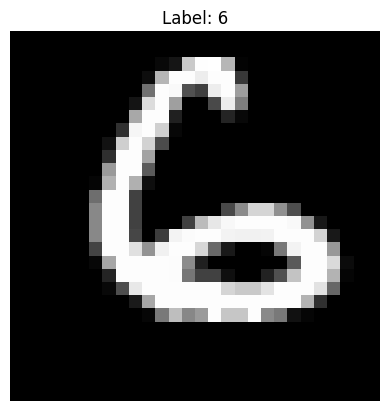

In [11]:
single_digit = X_train[0].reshape(28, 28)

plt.imshow(single_digit, cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

## Convert to Tensors

In [12]:
Xtr = torch.tensor(X_train_scaled, dtype=torch.float32)
ytr = torch.tensor(y_train.astype(int), dtype=torch.long)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32)
yte = torch.tensor(y_test.astype(int), dtype=torch.long)

print(f"Training data shape: {Xtr.shape}, Training data type: {Xtr.dtype}")
print(f"Training labels shape: {ytr.shape}, Training labels type: {ytr.dtype}")
print(f"Testing data shape: {Xte.shape}, Testing data type: {Xte.dtype}")
print(f"Testing labels shape: {yte.shape}, Testing labels type: {yte.dtype}")

Training data shape: torch.Size([60000, 784]), Training data type: torch.float32
Training labels shape: torch.Size([60000]), Training labels type: torch.int64
Testing data shape: torch.Size([10000, 784]), Testing data type: torch.float32
Testing labels shape: torch.Size([10000]), Testing labels type: torch.int64


# Creating the Network

## Network 1

In [34]:
g = torch.Generator().manual_seed(15623587590)
w1 = torch.randn(784, 28, generator=g) # 784 input features, 28 neurons in the hidden layer
b1 = torch.randn(28, generator=g)      # Bias for the hidden layer
w2 = torch.randn(28, 10, generator=g)  # 28 neurons in hidden layer, 10 output classes
b2 = torch.randn(10, generator=g)      # Bias for the output layer
parameters = [w1, b1, w2, b2]

In [ ]:
# Total number of parameters
sum(p.nelement() for p in parameters)

22270

In [36]:
# Setting the requires grad flag to True for all parameters
for p in parameters:
    p.requires_grad = True

In [38]:
for i in range(1000):
    
    # Minibatch
    ix = torch.randint(0, len(Xtr), (32,))
    
    # Forward pass
    o1 = torch.tanh(Xtr[ix] @ w1 + b1)  # Hidden layer activations (32 x 28)
    logits = o1 @ w2 + b2 # Output logits (32 x 10)
    loss = F.cross_entropy(logits, ytr[ix]) # Finds the loss
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if ((i+1) % 50 == 0):
        predictions = torch.argmax(logits, dim=1)
        batch_accuracy = (predictions == ytr[ix]).float().mean().item()
        print(f'Iteration: {i+1} | Loss: {loss.item():.4f} | Batch Accuracy: {batch_accuracy * 100:.2f}%')


with torch.no_grad():
    full_o1 = torch.tanh(Xtr @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == ytr).sum().item()
    total = ytr.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Training Dataset Accuracy: {total_accuracy:.2f}%')
    

Iteration: 50 | Loss: 0.9620 | Batch Accuracy: 65.62%
Iteration: 100 | Loss: 0.9969 | Batch Accuracy: 68.75%
Iteration: 150 | Loss: 1.2906 | Batch Accuracy: 62.50%
Iteration: 200 | Loss: 1.6400 | Batch Accuracy: 65.62%
Iteration: 250 | Loss: 0.9985 | Batch Accuracy: 71.88%
Iteration: 300 | Loss: 0.8584 | Batch Accuracy: 71.88%
Iteration: 350 | Loss: 0.7702 | Batch Accuracy: 75.00%
Iteration: 400 | Loss: 0.7075 | Batch Accuracy: 81.25%
Iteration: 450 | Loss: 0.7474 | Batch Accuracy: 68.75%
Iteration: 500 | Loss: 0.6740 | Batch Accuracy: 78.12%
Iteration: 550 | Loss: 0.8741 | Batch Accuracy: 71.88%
Iteration: 600 | Loss: 0.6355 | Batch Accuracy: 84.38%
Iteration: 650 | Loss: 0.7880 | Batch Accuracy: 75.00%
Iteration: 700 | Loss: 0.7455 | Batch Accuracy: 68.75%
Iteration: 750 | Loss: 1.0181 | Batch Accuracy: 62.50%
Iteration: 800 | Loss: 0.5961 | Batch Accuracy: 75.00%
Iteration: 850 | Loss: 0.9129 | Batch Accuracy: 75.00%
Iteration: 900 | Loss: 1.0554 | Batch Accuracy: 65.62%
Iteration: 

In [ ]:
# Predictions loss
o1 = torch.tanh(Xte @ w1 + b1)  # Hidden layer activations (60,000 x 28)
logits = o1 @ w2 + b2 # Output logits (60,000 x 10)
loss = F.cross_entropy(logits, yte) # Finds the loss
print(f'Loss: {loss.item():.4f}')

with torch.no_grad():
    full_o1 = torch.tanh(Xte @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == yte).sum().item()
    total = yte.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Test Dataset Accuracy: {total_accuracy:.2f}%')

Loss: 0.8703871965408325

Final Test Dataset Accuracy: 72.12%


## Network 2
Increased number of hidden neurons on layer 1

In [40]:
g = torch.Generator().manual_seed(15623587590)
w1 = torch.randn(784, 100, generator=g) # 784 input features, 28 neurons in the hidden layer
b1 = torch.randn(100, generator=g)      # Bias for the hidden layer
w2 = torch.randn(100, 10, generator=g)  # 28 neurons in hidden layer, 10 output classes
b2 = torch.randn(10, generator=g)      # Bias for the output layer
parameters = [w1, b1, w2, b2]

In [41]:
# Total number of parameters
sum(p.nelement() for p in parameters)

79510

In [42]:
# Setting the requires grad flag to True for all parameters
for p in parameters:
    p.requires_grad = True

In [44]:
for i in range(1000):
    
    # Minibatch
    ix = torch.randint(0, len(Xtr), (32,))
    
    # Forward pass
    o1 = torch.tanh(Xtr[ix] @ w1 + b1)  # Hidden layer activations (32 x 28)
    logits = o1 @ w2 + b2 # Output logits (32 x 10)
    loss = F.cross_entropy(logits, ytr[ix]) # Finds the loss
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if ((i+1) % 50 == 0):
        predictions = torch.argmax(logits, dim=1)
        batch_accuracy = (predictions == ytr[ix]).float().mean().item()
        print(f'Iteration: {i+1} | Loss: {loss.item():.4f} | Batch Accuracy: {batch_accuracy * 100:.2f}%')


with torch.no_grad():
    full_o1 = torch.tanh(Xtr @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == ytr).sum().item()
    total = ytr.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Training Dataset Accuracy: {total_accuracy:.2f}%')
    

Iteration: 50 | Loss: 0.9172 | Batch Accuracy: 81.25%
Iteration: 100 | Loss: 1.1456 | Batch Accuracy: 84.38%
Iteration: 150 | Loss: 1.4166 | Batch Accuracy: 78.12%
Iteration: 200 | Loss: 2.6272 | Batch Accuracy: 62.50%
Iteration: 250 | Loss: 0.7991 | Batch Accuracy: 90.62%
Iteration: 300 | Loss: 1.3122 | Batch Accuracy: 84.38%
Iteration: 350 | Loss: 0.3530 | Batch Accuracy: 90.62%
Iteration: 400 | Loss: 2.2791 | Batch Accuracy: 68.75%
Iteration: 450 | Loss: 1.3518 | Batch Accuracy: 78.12%
Iteration: 500 | Loss: 1.0068 | Batch Accuracy: 81.25%
Iteration: 550 | Loss: 0.7461 | Batch Accuracy: 81.25%
Iteration: 600 | Loss: 2.1623 | Batch Accuracy: 81.25%
Iteration: 650 | Loss: 2.2104 | Batch Accuracy: 81.25%
Iteration: 700 | Loss: 0.7265 | Batch Accuracy: 84.38%
Iteration: 750 | Loss: 1.2750 | Batch Accuracy: 78.12%
Iteration: 800 | Loss: 1.0397 | Batch Accuracy: 81.25%
Iteration: 850 | Loss: 0.9449 | Batch Accuracy: 81.25%
Iteration: 900 | Loss: 1.2367 | Batch Accuracy: 81.25%
Iteration: 

In [45]:
# Predictions loss
o1 = torch.tanh(Xte @ w1 + b1)  # Hidden layer activations (60,000 x 28)
logits = o1 @ w2 + b2 # Output logits (60,000 x 10)
loss = F.cross_entropy(logits, yte) # Finds the loss
print(f'Loss: {loss.item():.4f}')

with torch.no_grad():
    full_o1 = torch.tanh(Xte @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == yte).sum().item()
    total = yte.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Test Dataset Accuracy: {total_accuracy:.2f}%')

Loss: 1.2602

Final Test Dataset Accuracy: 79.90%


## Network 3
Change the activation function to ReLU

In [60]:
g = torch.Generator().manual_seed(15623587590)
w1 = torch.randn(784, 100, generator=g) * (2.0 / 784)**0.5 # 784 input features, 28 neurons in the hidden layer
b1 = torch.randn(100, generator=g)      # Bias for the hidden layer
w2 = torch.randn(100, 10, generator=g) * (2.0 / 100)**0.5 # 28 neurons in hidden layer, 10 output classes
b2 = torch.randn(10, generator=g)      # Bias for the output layer
parameters = [w1, b1, w2, b2]

In [ ]:
# Total number of parameters
sum(p.nelement() for p in parameters)

79510

In [62]:
# Setting the requires grad flag to True for all parameters
for p in parameters:
    p.requires_grad = True

In [64]:
for i in range(1000):
    
    # Minibatch
    ix = torch.randint(0, len(Xtr), (32,))
    
    # Forward pass
    o1 = torch.relu(Xtr[ix] @ w1 + b1)  # Hidden layer activations (32 x 28)
    logits = o1 @ w2 + b2 # Output logits (32 x 10)
    loss = F.cross_entropy(logits, ytr[ix]) # Finds the loss
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if ((i+1) % 50 == 0):
        predictions = torch.argmax(logits, dim=1)
        batch_accuracy = (predictions == ytr[ix]).float().mean().item()
        print(f'Iteration: {i+1} | Loss: {loss.item():.4f} | Batch Accuracy: {batch_accuracy * 100:.2f}%')


with torch.no_grad():
    full_o1 = torch.relu(Xtr @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == ytr).sum().item()
    total = ytr.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Training Dataset Accuracy: {total_accuracy:.2f}%')
    

Iteration: 50 | Loss: 0.0469 | Batch Accuracy: 100.00%
Iteration: 100 | Loss: 0.1795 | Batch Accuracy: 93.75%
Iteration: 150 | Loss: 0.1720 | Batch Accuracy: 93.75%
Iteration: 200 | Loss: 0.0924 | Batch Accuracy: 100.00%
Iteration: 250 | Loss: 0.3600 | Batch Accuracy: 93.75%
Iteration: 300 | Loss: 0.1253 | Batch Accuracy: 96.88%
Iteration: 350 | Loss: 0.6061 | Batch Accuracy: 93.75%
Iteration: 400 | Loss: 0.2395 | Batch Accuracy: 93.75%
Iteration: 450 | Loss: 0.6114 | Batch Accuracy: 90.62%
Iteration: 500 | Loss: 0.2498 | Batch Accuracy: 93.75%
Iteration: 550 | Loss: 0.1150 | Batch Accuracy: 93.75%
Iteration: 600 | Loss: 0.0860 | Batch Accuracy: 100.00%
Iteration: 650 | Loss: 0.2015 | Batch Accuracy: 87.50%
Iteration: 700 | Loss: 0.0266 | Batch Accuracy: 100.00%
Iteration: 750 | Loss: 0.0444 | Batch Accuracy: 100.00%
Iteration: 800 | Loss: 0.1019 | Batch Accuracy: 93.75%
Iteration: 850 | Loss: 0.1847 | Batch Accuracy: 93.75%
Iteration: 900 | Loss: 0.1220 | Batch Accuracy: 96.88%
Iterat

In [65]:
# Predictions loss
o1 = torch.relu(Xte @ w1 + b1)  # Hidden layer activations (60,000 x 28)
logits = o1 @ w2 + b2 # Output logits (60,000 x 10)
loss = F.cross_entropy(logits, yte) # Finds the loss
print(f'Loss: {loss.item():.4f}')

with torch.no_grad():
    full_o1 = torch.relu(Xte @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == yte).sum().item()
    total = yte.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Test Dataset Accuracy: {total_accuracy:.2f}%')

Loss: 0.5887

Final Test Dataset Accuracy: 94.92%


## Network 4

Initalize biases with 0 and increase the training time

In [76]:
g = torch.Generator().manual_seed(15623587590)
w1 = torch.randn(784, 100, generator=g) * (2.0 / 784)**0.5 # 784 input features, 28 neurons in the hidden layer
b1 = torch.zeros(100)      # Bias for the hidden layer
w2 = torch.randn(100, 10, generator=g) * (2.0 / 100)**0.5 # 28 neurons in hidden layer, 10 output classes
b2 = torch.zeros(10)      # Bias for the output layer
parameters = [w1, b1, w2, b2]

In [77]:
# Total number of parameters
sum(p.nelement() for p in parameters)

79510

In [78]:
# Setting the requires grad flag to True for all parameters
for p in parameters:
    p.requires_grad = True

In [79]:
loss_history = []
acc_history = []
iter_history = []

for i in range(3000):
    
    # Minibatch
    ix = torch.randint(0, len(Xtr), (32,))
    
    # Forward pass
    o1 = torch.relu(Xtr[ix] @ w1 + b1)  # Hidden layer activations (32 x 28)
    logits = o1 @ w2 + b2 # Output logits (32 x 10)
    loss = F.cross_entropy(logits, ytr[ix]) # Finds the loss
    
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update
    lr = 0.1
    if(i > 2000): lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if ((i+1) % 50 == 0):
        predictions = torch.argmax(logits, dim=1)
        batch_accuracy = (predictions == ytr[ix]).float().mean().item()
        print(f'Iteration: {i+1} | Loss: {loss.item():.4f} | Batch Accuracy: {batch_accuracy * 100:.2f}%')
        
        loss_history.append(loss.item())
        acc_history.append(batch_accuracy * 100)
        iter_history.append(i+1)


with torch.no_grad():
    full_o1 = torch.relu(Xtr @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == ytr).sum().item()
    total = ytr.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Training Dataset Accuracy: {total_accuracy:.2f}%')
    

Iteration: 50 | Loss: 0.4241 | Batch Accuracy: 90.62%
Iteration: 100 | Loss: 0.3811 | Batch Accuracy: 90.62%
Iteration: 150 | Loss: 0.1852 | Batch Accuracy: 93.75%
Iteration: 200 | Loss: 0.3074 | Batch Accuracy: 93.75%
Iteration: 250 | Loss: 2.0499 | Batch Accuracy: 81.25%
Iteration: 300 | Loss: 0.2965 | Batch Accuracy: 87.50%
Iteration: 350 | Loss: 0.1703 | Batch Accuracy: 96.88%
Iteration: 400 | Loss: 0.1401 | Batch Accuracy: 93.75%
Iteration: 450 | Loss: 0.0812 | Batch Accuracy: 100.00%
Iteration: 500 | Loss: 0.0324 | Batch Accuracy: 100.00%
Iteration: 550 | Loss: 0.1519 | Batch Accuracy: 96.88%
Iteration: 600 | Loss: 0.2311 | Batch Accuracy: 90.62%
Iteration: 650 | Loss: 0.2227 | Batch Accuracy: 93.75%
Iteration: 700 | Loss: 0.1067 | Batch Accuracy: 96.88%
Iteration: 750 | Loss: 0.0863 | Batch Accuracy: 96.88%
Iteration: 800 | Loss: 0.1216 | Batch Accuracy: 93.75%
Iteration: 850 | Loss: 0.1269 | Batch Accuracy: 96.88%
Iteration: 900 | Loss: 0.0506 | Batch Accuracy: 100.00%
Iteratio

In [80]:
# Predictions loss
o1 = torch.relu(Xte @ w1 + b1)  # Hidden layer activations (60,000 x 28)
logits = o1 @ w2 + b2 # Output logits (60,000 x 10)
loss = F.cross_entropy(logits, yte) # Finds the loss
print(f'Loss: {loss.item():.4f}')

with torch.no_grad():
    full_o1 = torch.relu(Xte @ w1 + b1)
    full_logits = full_o1 @ w2 + b2
    
    full_preds = torch.argmax(full_logits, dim=1)
    
    correct = (full_preds == yte).sum().item()
    total = yte.size(0)
    
    total_accuracy = (correct / total) * 100
    print(f'\nFinal Test Dataset Accuracy: {total_accuracy:.2f}%')

Loss: 0.9818

Final Test Dataset Accuracy: 96.10%


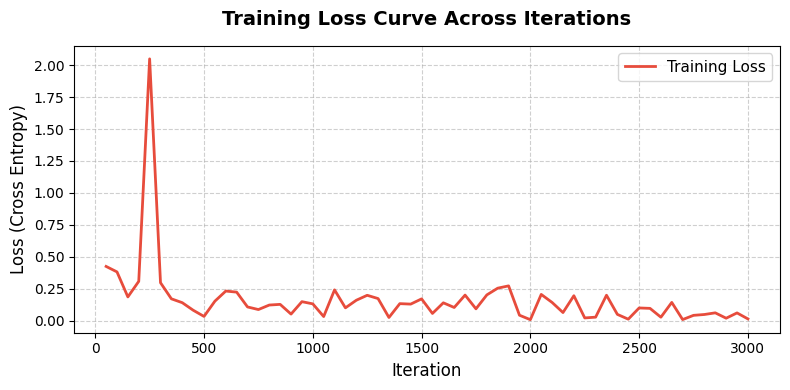

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iter_history, loss_history, color='#E74C3C', linewidth=2, label='Training Loss')
ax.set_title('Training Loss Curve Across Iterations', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (Cross Entropy)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

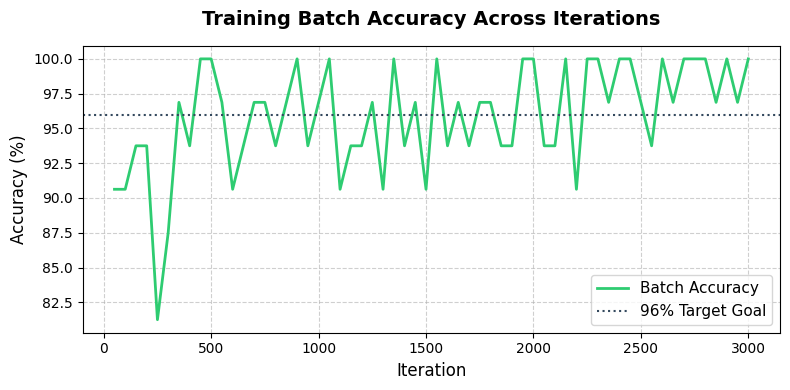

In [82]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iter_history, acc_history, color='#2ECC71', linewidth=2, label='Batch Accuracy')
ax.axhline(96.0, color='#34495E', linestyle=':', linewidth=1.5, label='96% Target Goal')
ax.set_title('Training Batch Accuracy Across Iterations', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

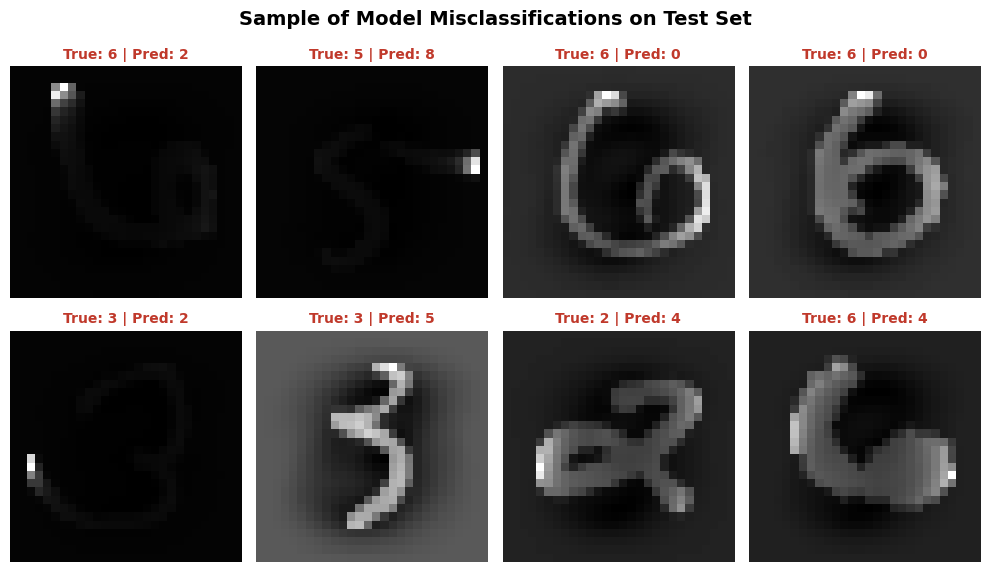

In [83]:
with torch.no_grad():
    test_o1 = torch.relu(Xte @ w1 + b1)
    test_logits = test_o1 @ w2 + b2
    test_preds = torch.argmax(test_logits, dim=1)

# Get indices where the prediction does not equal the true label
misclassified_idx = (test_preds != yte).nonzero(as_tuple=True)[0]

# Plot a 2x4 grid of mistakes
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx >= len(misclassified_idx):
        break
    img_idx = misclassified_idx[idx].item()
    
    # Reshape back to 28x28 for visualization
    img = Xte[img_idx].view(28, 28).numpy()
    true_label = yte[img_idx].item()
    pred_label = test_preds[img_idx].item()
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color='#C0392B', fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Sample of Model Misclassifications on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()